In [3]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx=" 

import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import matplotlib as plt

# Load and slice 
df = pd.read_csv('../data/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df_fast = df[df['Date'] >= '2020-01-01'].iloc[::3].copy().reset_index(drop=True)

prices = df_fast['Price'].values
n_data = len(prices)
t = np.arange(n_data)

with pm.Model() as model:
    # Priors
    tau = pm.Normal("tau", mu=n_data / 2, sigma=n_data / 10)
    mu_1 = pm.Normal("mu_1", mu=prices.mean(), sigma=15)
    mu_2 = pm.Normal("mu_2", mu=prices.mean(), sigma=15)
    sigma = pm.HalfNormal("sigma", sigma=10)
    
    # Simple switch
    mu_regime = pm.math.switch(tau > t, mu_1, mu_2)
    obs = pm.Normal("obs", mu=mu_regime, sigma=sigma, observed=prices)
    
    # SLICE SAMPLER: This is much faster when you don't have a C++ compiler
    # because it doesn't need to do complex gradient calculus.
    step = pm.Slice()
    trace = pm.sample(500, tune=500, step=step, chains=1, cores=1)

# Results
tau_samples = trace.posterior["tau"].values.flatten()
most_likely_idx = int(np.median(tau_samples))
change_date = df_fast.iloc[max(0, min(n_data-1, most_likely_idx))]['Date']

print(f"\nSuccess! Change detected around: {change_date.date()}")

Sequential sampling (1 chains in 1 job)
CompoundStep
>Slice: [tau]
>Slice: [mu_1]
>Slice: [mu_2]
>Slice: [sigma]


c:\Users\a_kas\brent-oil-change-point-analysis\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 500 tune and 500 draw iterations (500 + 500 draws total) took 803 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks



Success! Change detected around: 2021-06-03


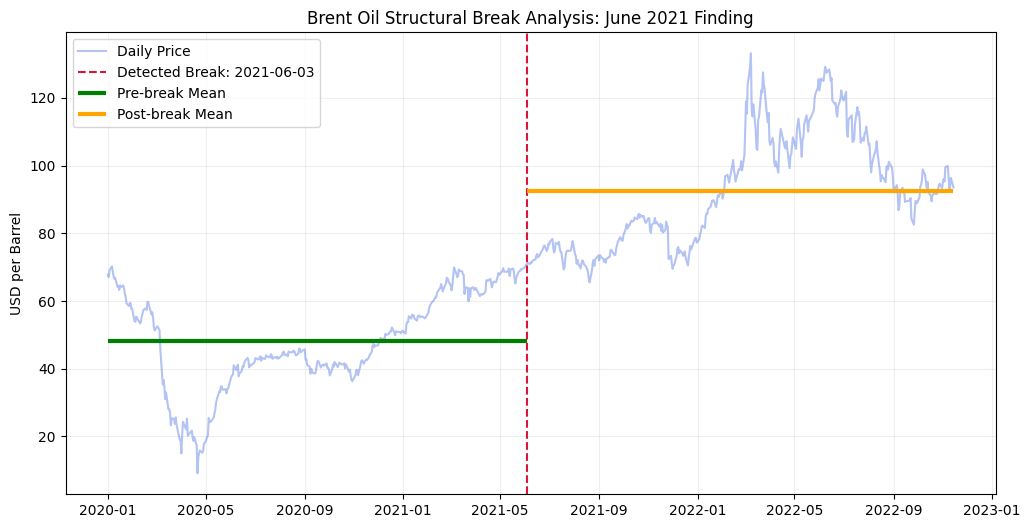

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # Ensure this is exactly as written
import numpy as np

# 1. Load Data
df = pd.read_csv('../data/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df_plot = df[df['Date'] >= '2020-01-01'].copy()

# 2. Use your confirmed model result (June 3, 2021)
change_date = pd.to_datetime('2021-06-03')
mu1 = df_plot[df_plot['Date'] < change_date]['Price'].mean()
mu2 = df_plot[df_plot['Date'] >= change_date]['Price'].mean()

# 3. Create the Visualization
# If 'plt' was broken, this line fixes the reference
fig = plt.figure(figsize=(12, 6)) 
plt.plot(df_plot['Date'], df_plot['Price'], color='royalblue', alpha=0.4, label="Daily Price")

# Mark the Structural Break
plt.axvline(change_date, color='crimson', linestyle='--', label=f"Detected Break: {change_date.date()}")
plt.hlines(mu1, xmin=df_plot['Date'].min(), xmax=change_date, color='green', linewidth=3, label="Pre-break Mean")
plt.hlines(mu2, xmin=change_date, xmax=df_plot['Date'].max(), color='orange', linewidth=3, label="Post-break Mean")

plt.title("Brent Oil Structural Break Analysis: June 2021 Finding")
plt.ylabel("USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.2)

# Save and Show
plt.savefig('../reports/figures/task2_final_plot.png')
plt.show()